In [15]:
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt

import pandas as pd

In [16]:
sheet_id = "1UVo7wPeu2HXRQ1Zm8VTa4v2Bui2shyrRskHduYHttCw"
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv"

df = pd.read_csv(url)

# --- 2. Keep only first 18 rows ---
df = df.iloc[:17]

# --- 3. Rename columns (shorter names) ---
df.columns = [
    "verb", "miguel_pres", "knapp_pres", "miguel_res", "knapp_res",
    "todo_constr", "todo_total", "todo_ratio",
    "es_constr", "es_total", "es_ratio",
    "am_constr", "am_total", "am_ratio",
    "mx_constr", "mx_total", "mx_ratio"
]

df.head()

,verb,miguel_pres,knapp_pres,miguel_res,knapp_res,todo_constr,todo_total,todo_ratio,es_constr,es_total,es_ratio,am_constr,am_total,am_ratio,mx_constr,mx_total,mx_ratio
0,escurrir,sí,no,Dudoso,NaN,5.0,4930.0,"1,01E-03",4.0,1654.0,"2,42E-03",1.0,3269.0,"3,06E-04",NaN,1084.0,NaN
1,arribar,sí,no,Bien,NaN,4.0,5927.0,"6,75E-04",1.0,435.0,"2,30E-03",2.0,5463.0,"3,66E-04",NaN,1045.0,NaN
2,llegar,sí,sí,Bien,Bien,179.0,478813.0,"3,74E-04",76.0,174444.0,"4,36E-04",97.0,302806.0,"3,20E-04",15.0,51619.0,"2,91E-04"
3,rodar,sí,no,Mal,NaN,2.0,11828.0,"1,69E-04",1.0,5801.0,"1,72E-04",1.0,5999.0,"1,67E-04",NaN,964.0,NaN
4,caer,sí,sí,Bien,Bien,16.0,120744.0,"1,33E-04",5.0,43759.0,"1,14E-04",10.0,76681.0,"1,30E-04",NaN,13731.0,NaN


In [17]:
df.iloc[:, :5] = df.iloc[:, :5].astype(str)

In [18]:
for col in df.columns[6:]:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
    )

    df[col] = pd.to_numeric(df[col], errors="coerce")

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   verb         17 non-null     str    
 1   miguel_pres  17 non-null     str    
 2   knapp_pres   17 non-null     str    
 3   miguel_res   17 non-null     str    
 4   knapp_res    11 non-null     str    
 5   todo_constr  17 non-null     float64
 6   todo_total   17 non-null     float64
 7   todo_ratio   17 non-null     float64
 8   es_constr    14 non-null     float64
 9   es_total     17 non-null     float64
 10  es_ratio     14 non-null     float64
 11  am_constr    15 non-null     float64
 12  am_total     17 non-null     float64
 13  am_ratio     15 non-null     float64
 14  mx_constr    5 non-null      float64
 15  mx_total     17 non-null     float64
 16  mx_ratio     5 non-null      float64
dtypes: float64(12), str(5)
memory usage: 2.7 KB


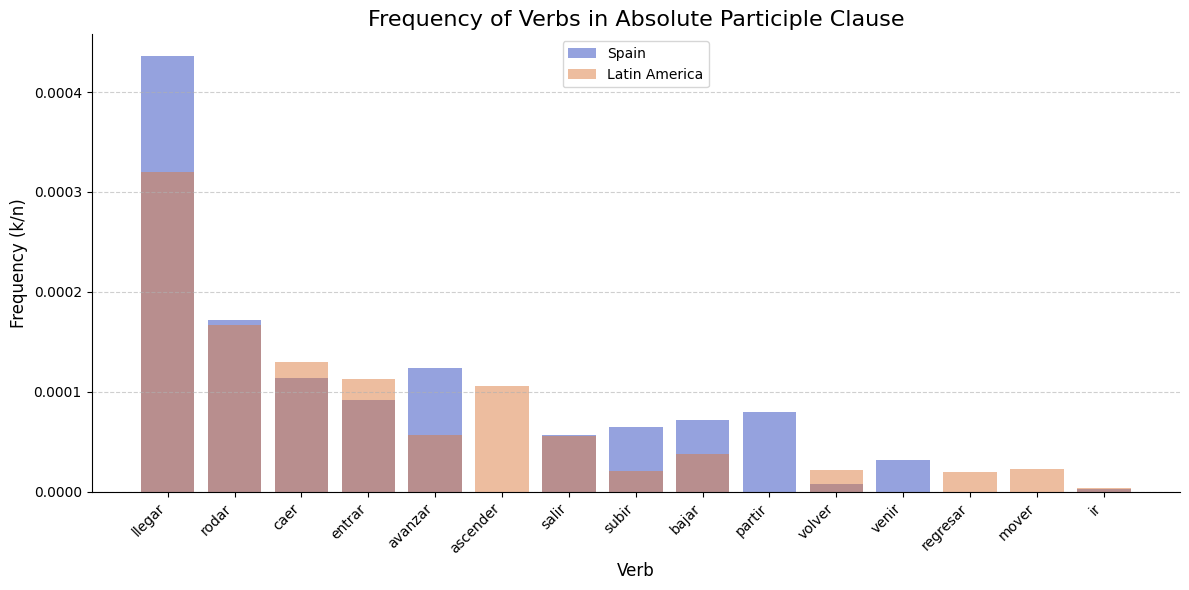

In [25]:
plt.figure(figsize=(12, 6))

bars_es = plt.bar(df["verb"].iloc[2:], df["es_ratio"].iloc[2:], color="#2c47bf", alpha=0.5, label = "Spain")  # es
bars_la = plt.bar(df["verb"].iloc[2:], df["am_ratio"].iloc[2:], color="#DC7C40", alpha=0.5, label = "Latin America")  # la
# Styling
plt.title("Frequency of Verbs in Absolute Participle Clause", fontsize=16)
plt.xlabel("Verb", fontsize=12)
plt.ylabel("Frequency (k/n)", fontsize=12)

plt.xticks(rotation=45, ha="right")

# Grid for readability
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.legend()

# Remove top/right spines for cleaner look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [27]:
df["todo_diff"] = df["todo_total"] - df["todo_constr"]
df.head()

,verb,miguel_pres,knapp_pres,miguel_res,knapp_res,todo_constr,todo_total,todo_ratio,es_constr,es_total,es_ratio,am_constr,am_total,am_ratio,mx_constr,mx_total,mx_ratio,todo_diff
0,escurrir,sí,no,Dudoso,NaN,5.0,4930.0,0.001010,4.0,1654.0,0.002420,1.0,3269.0,0.000306,NaN,1084.0,NaN,4925.0
1,arribar,sí,no,Bien,NaN,4.0,5927.0,0.000675,1.0,435.0,0.002300,2.0,5463.0,0.000366,NaN,1045.0,NaN,5923.0
2,llegar,sí,sí,Bien,Bien,179.0,478813.0,0.000374,76.0,174444.0,0.000436,97.0,302806.0,0.000320,15.0,51619.0,0.000291,478634.0
3,rodar,sí,no,Mal,NaN,2.0,11828.0,0.000169,1.0,5801.0,0.000172,1.0,5999.0,0.000167,NaN,964.0,NaN,11826.0
4,caer,sí,sí,Bien,Bien,16.0,120744.0,0.000133,5.0,43759.0,0.000114,10.0,76681.0,0.000130,NaN,13731.0,NaN,120728.0


In [54]:
to_test = np.array([
    [c, t - c] for c, t in zip(df["todo_constr"], df["todo_total"])
])

print("TODO EL CORPUS. H0: la frecuencia del uso de los verbos en la construcción es igual para todos los verbos, los verbos más frecuentes en el corpus aparecen con más frecuencia en la construcción y nada más")
chi2, p, dof, expected = chi2_contingency(to_test)
print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)
print("Expected frequencies:\n", expected)
print("H0 rejected")

TODO EL CORPUS. H0: la frecuencia del uso de los verbos en la construcción es igual para todos los verbos, los verbos más frecuentes en el corpus aparecen con más frecuencia en la construcción y nada más
Chi-square: 926.023614647928
p-value: 7.583023007110059e-187
Degrees of freedom: 16
Expected frequencies:
 [[3.33000026e-01 4.92966700e+03]
 [4.00343034e-01 5.92659966e+03]
 [3.23417326e+01 4.78780658e+05]
 [7.98929880e-01 1.18272011e+04]
 [8.15573127e+00 1.20735844e+05]
 [1.10290554e+01 1.63271971e+05]
 [3.48008668e+00 5.15185199e+04]
 [1.04790313e+00 1.55129521e+04]
 [1.93268352e+01 2.86110673e+05]
 [5.43580327e+00 8.04705642e+04]
 [5.49173106e+00 8.12985083e+04]
 [2.65933956e+00 3.93683407e+04]
 [2.06282371e+01 3.05376372e+05]
 [1.73846953e+01 2.57359615e+05]
 [4.70259530e+00 6.96162974e+04]
 [4.89564075e+00 7.24741044e+04]
 [1.36888340e+02 2.02646811e+06]]
H0 rejected


In [ ]:
residuals = (to_test - expected) / np.sqrt(expected)
# print("Residuals", residuals)
for i, r in enumerate(residuals[:, 0]):
        if abs(r) > 2:
            print(f"Verb {df.iloc[i]["verb"]} is unusual: residual = {r:.2f}")

Verb escurrir is unusual: residual = 8.09
Verb arribar is unusual: residual = 5.69
Verb llegar is unusual: residual = 25.79
Verb caer is unusual: residual = 2.75
Verb volver is unusual: residual = -3.00
Verb venir is unusual: residual = -3.21
Verb ir is unusual: residual = -11.10


In [58]:
summary = pd.DataFrame({
    "verb": df["verb"],
    "obs_constr": to_test[:, 0],
    "exp_constr": expected[:, 0],
    "residual": residuals[:, 0],
    "freq": df["todo_constr"] / df["todo_total"]
})

summary["effect"] = summary["residual"].apply(
    lambda x: "more frequent" if x > 2 else ("less frequent" if x < -2 else "neutral")
)
summary = summary.sort_values(by="residual", key=abs, ascending=False)
summary

,verb,obs_constr,exp_constr,residual,freq,effect
2,llegar,179.0,32.341733,25.788430,0.000374,more frequent
16,ir,7.0,136.888340,-11.101635,0.000003,less frequent
0,escurrir,5.0,0.333000,8.087526,0.001014,more frequent
1,arribar,4.0,0.400343,5.689118,0.000675,more frequent
13,venir,4.0,17.384695,-3.210147,0.000016,less frequent
12,volver,7.0,20.628237,-3.000604,0.000023,less frequent
4,caer,16.0,8.155731,2.746762,0.000133,more frequent
5,entrar,17.0,11.029055,1.797935,0.000104,neutral
15,mover,1.0,4.895641,-1.760654,0.000014,neutral
14,regresar,1.0,4.702595,-1.707409,0.000014,neutral


In [64]:
# Rows = verbs
# Columns = regions (Spain vs America)
# Is Spain different from LA for certain verbs?

# Keep only relevant columns
sub = df[["es_ratio", "am_ratio"]].copy()

# Remove missing values
sub = sub.dropna()

# Remove rows where both are zero
sub = sub[(sub["es_ratio"] + sub["am_ratio"]) > 0]

table = sub[["es_ratio", "am_ratio"]].to_numpy()

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)

print("H0 is not rejected")

Chi-square: 0.0010269928825759735
p-value: 1.0
H0 is not rejected
